# Simulations V3

## Import

In [1]:
import numpy as np
import pandas as pd
import bincatsim as bs
import astropy.units as u
from matplotlib import pyplot as plt
from scipy.signal import argrelextrema
from importlib import reload
from tqdm import tqdm

import grasp as gp
stats = gp.stats

home = '/home/pietrof'

lf = gp.plots.label_font
lf['size'] = 18

tf = gp.plots.title_font
tf['size'] = 22

def plot_groups(
    data,
    x,
    y,
    hue:str = None,
    hue_label:str = None,
    xlabel: str = None,
    ylabel: str = None,
    title : str =None,
    **kwargs
):
    fs = kwargs.pop('figsize', (10,8))
    lon = kwargs.pop('legend', True)
    yscale = kwargs.pop('yscale', None)
    if hue is not None:
        if isinstance(hue, str) and hue in data.columns:
            data = {dm: data[data[hue] == dm] for dm in data[hue].unique()} if hue else data
        else:
            try:
                data = {0: data[hue]}
                lon = False
            except Exception as e:
                print(f"Error processing hue: {e}")
                data = {0: data}
                lon = False
    else:
        data = {0: data}
        lon = False

    plt.figure(figsize=fs)
    for dm, group in data.items():
        plt.plot(group[x], group[y], '-o', label=f'{hue_label or hue} = {float(dm):.2}', alpha=0.7, **kwargs)
    plt.xlabel(xlabel or x, fontdict=gp.plots.label_font)
    plt.ylabel(ylabel or y, fontdict=gp.plots.label_font)
    plt.title(title or f"{y.upper()} vs {x.upper()}", fontdict=gp.plots.title_font)
    plt.grid(linestyle='--', alpha=0.5)
    if lon:
        plt.legend(title='HUE', loc='best', fontsize='large')
    if yscale:
        plt.yscale(yscale)
    plt.tick_params(axis='both', labelsize=14)
    plt.show()
    

sd = pd.read_csv(bs.paths.SIM_RECORD_FILE)
sd = sd[sd['D_mas'] < 221]


[XuPy] Device 0 available - GPU : `NVIDIA GeForce RTX 5080 Laptop GPU`
       Memory = 16220.22 MB | Compute Capability = 12.0
       Using CuPy 13.6.0 for acceleration.


/home/pietrof/miniforge3/envs/bincat/lib/python3.13/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


## Visualizations

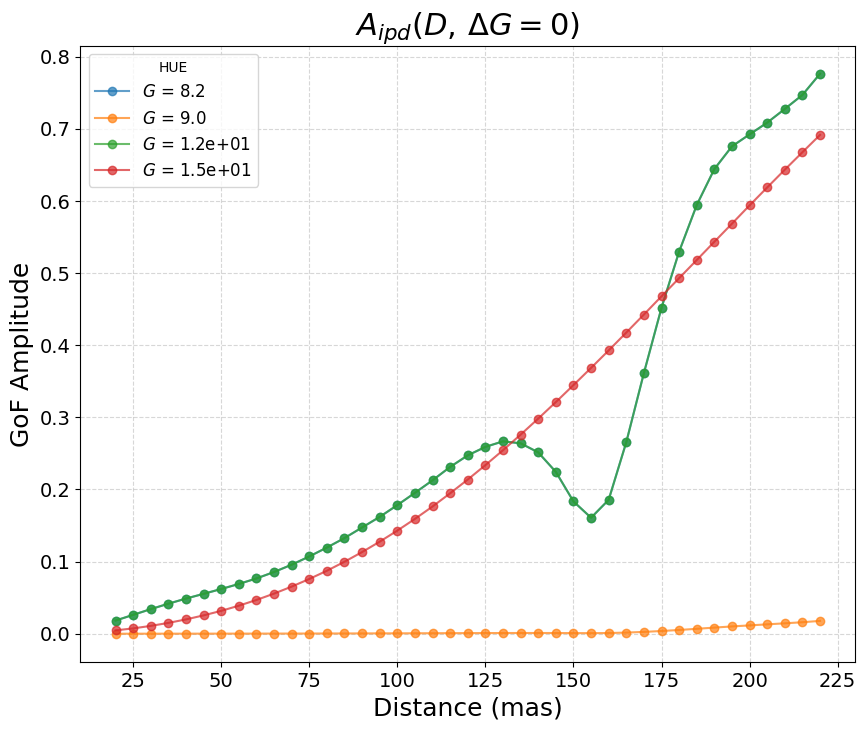

In [ ]:
plot_groups(
    sd[(sd['delta_m'].isin([0,4])) & (sd['D_mas'] < 221)],
    x='D_mas',
    y='gof_amp', 
    hue='G',
    hue_label=r"$G$",
    xlabel='Distance (mas)', 
    ylabel='GoF Amplitude',
    title=r'$A_{ipd}(D,\,\Delta G=0)$'
)

In [ ]:
delta_bright = {x: sd[(sd['delta_m'] == x) & (sd['G'] < 10)] for x in range(4)}
delta_faint = {x: sd[(sd['delta_m'] == x) & (sd['G'] > 15)] for x in range(4)}

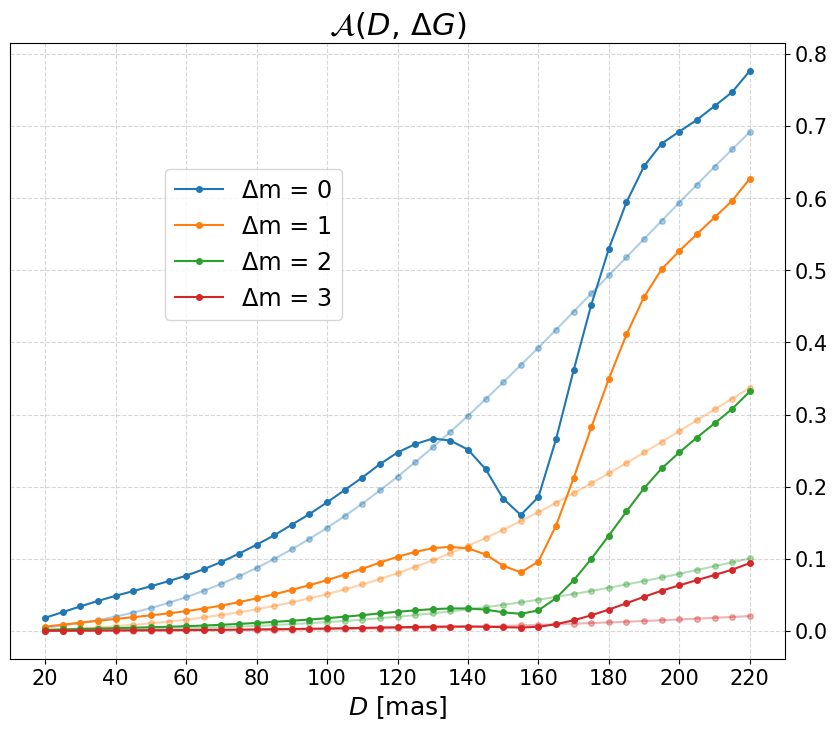

In [ ]:
plt.figure(figsize=(10,8))
for dm in range(4):
    plt.plot(delta_bright[dm]['D_mas'], delta_bright[dm]['gof_amp'], '-o', markersize=4, label=f'Δm = {dm}', alpha=1, c=f'C{dm}')
    plt.plot( delta_faint[dm]['D_mas'],  delta_faint[dm]['gof_amp'], '-o', markersize=4, alpha=0.35, c=f'C{dm}')
plt.xlabel(r'$D$ [mas]', fontdict=gp.plots.label_font)
# plt.ylabel(r'$\mathcal{A}$', fontdict=gp.plots.label_font)
plt.title(r'$\mathcal{A}(D,\,\Delta G)$', fontdict=gp.plots.title_font)
plt.grid(linestyle='--', alpha=0.5)
plt.legend(loc=(0.2, 0.55), fontsize='xx-large')
plt.xticks(ticks=np.arange(20,221, 20), fontsize=15)
ax = plt.gca()
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.tick_params(axis='y', labelsize=15, labelright=True, labelleft=False)
plt.show()

In [2]:
cube = bs.load_psf(sd[sd['D_mas'] == 200].iloc[0].TN)

In [3]:
ipd = bs.IPD(cube=cube)

In [4]:
cube[0].primary_meta

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   18                                                  
NAXIS2  =                   12                                                  
EXTEND  =                    T                                                  
DISTMAS =                  200 / Angular separation in mas                      
M1      =                  9.0 / Magnitude of the primary (central) star        
M2      =                  9.0 / Magnitude of the secondary (companion) star    
GMAG    =    8.247425010840047 / Calibration G-Magnitude of the expected source 
BAND    = 'Gaia_G  '           / Photometric band                               
WAVELEN =                673.0 / Effective wavelength in nm                     
ZP      =              30300

IPD(tn=None, gof_amp=6.92e-01, gof_phase=30.9 deg ipd_frac_multipeak=22.33%, ipd_frac_badfit=43.37%)

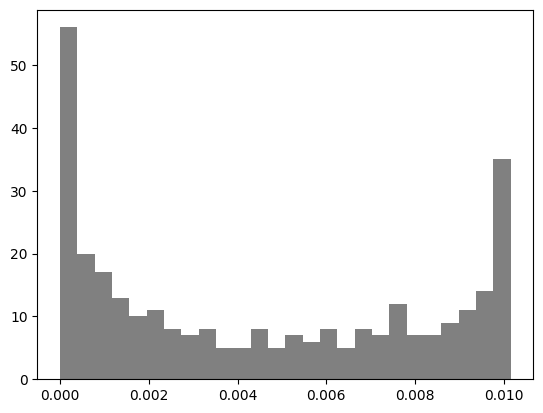

In [5]:
ipd()

findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive
findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


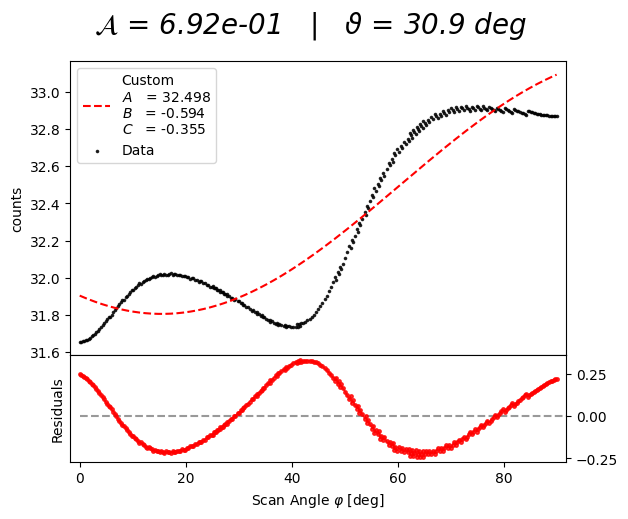

/mnt/nas/BINCAT/bincatsim/processing/ipd_.py:328: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


In [6]:
fig, fax = ipd.show_harmonic_fit()

In [8]:
fig.set_tight_layout(True)

In [9]:
fig.show()

/tmp/ipykernel_107025/89474557.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
